# Generative Model Comparison on MNIST

**Models:**

| Model | Status | Description |
|-------|--------|-------------|
| **Latent DDPM** | ✅ Implemented | DDPM in the latent space of a β-VAE |
| **DDPM (U-Net)** | ✅ Implemented | Pixel-space DDPM with U-Net backbone |
| **VAE** | ⬜ Placeholder | Standalone β-VAE (see `models/vae_model.py`) |

**Notebook structure:**
1. Setup — imports, hyperparameters, data
2. Training — train each model
3. Evaluation — visual comparison, FID, sampling speed, latent analysis
4. Discussion

In [1]:
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

ROOT = Path.cwd().parent  # .../Advanced-Machine-learning
if str(ROOT) not in sys.path:
    
    sys.path.insert(0, str(ROOT))

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Root:   {ROOT}')


Device: cuda
Root:   c:\Users\berko\Documents\Code\Advanced-Machine-learning


In [2]:

# ─── Imports ──────────────────────────────────────────────────
# Force-reload LatentDDPMwNB modules so code changes are picked up
# without restarting the kernel.
import importlib, sys

for mod_name in sorted(k for k in sys.modules if k.startswith('LatentDDPMwNB')):
    importlib.reload(sys.modules[mod_name])

from LatentDDPMwNB.data import get_standard_mnist, get_ddpm_mnist, get_real_images_for_fid
from LatentDDPMwNB.compare import (
    show_samples, measure_sampling_speed, evaluate_fid,
    compare_models, plot_latent_distributions, fid_vs_beta,
)

# Model wrappers (auto-registers them in ModelRegistry)
from LatentDDPMwNB.models.ddpm_unet import DDPMUNetModel
from LatentDDPMwNB.models.vae_model import VAEModel
from LatentDDPMwNB.models.latent_ddpm import LatentDDPMModel
from LatentDDPMwNB.models.registry import ModelRegistry

print('Registered models:', ModelRegistry.list())


Registered models: ['ddpm_unet', 'vae', 'latent_ddpm']


In [3]:

# ─── Hyperparameters ──────────────────────────────────────────
BATCH_SIZE   = 64
LATENT_DIM   = 16
VAE_HIDDEN   = 2048
DDPM_T       = 1000

# Latent DDPM / β-VAE
# GaussianDecoder now uses fixed std=1 (non-learnable), so reconstruction and
# KL gradients are balanced. LDDPM_BETA=1.0 is genuine standard-VAE scale.
# β > 1 gives tighter latent alignment (try 1.0-2.0 range).
LDDPM_BETA              = 1.0   # Standard VAE scale now that decoder std is fixed at 1
LDDPM_VAE_EPOCHS        = 50 if device == 'cuda' else 60
LDDPM_VAE_WARMUP_EPOCHS = LDDPM_VAE_EPOCHS // 2
LDDPM_DDPM_EPOCHS       = 30 if device == 'cuda' else 20
LDDPM_VAE_LR            = 1e-3
LDDPM_DDPM_LR           = 2e-4

# DDPM U-Net
DDPM_UNET_EPOCHS  = 50 if device == 'cuda' else 10
DDPM_UNET_LR      = 2e-4

# FID
N_FID = 1000

# Output directory
OUTDIR = Path('project/outputs')
OUTDIR.mkdir(parents=True, exist_ok=True)


In [4]:
# ─── Data ─────────────────────────────────────────────────────
# Standard MNIST [0,1] — used by Latent DDPM and VAE
train_loader, test_loader = get_standard_mnist(BATCH_SIZE)

# DDPM MNIST [-1,1] — used by the pixel-space DDPM U-Net
train_loader_ddpm, _ = get_ddpm_mnist(BATCH_SIZE)

print(f'Train batches (standard): {len(train_loader)}')
print(f'Train batches (DDPM):     {len(train_loader_ddpm)}')

Train batches (standard): 938
Train batches (DDPM):     938


---
# 2. Training

## 2.1 Latent DDPM (β-VAE + DDPM in z-space)

In [5]:
latent_ddpm = LatentDDPMModel(
    device=device,
    beta=LDDPM_BETA,
    latent_dim=LATENT_DIM,
    vae_hidden=VAE_HIDDEN,
    T=DDPM_T,
)


In [6]:
# Stage 1: Train the β-VAE
print('Stage 1: Training β-VAE (Gaussian likelihood)...')

# Support both old/new class signatures if notebook kernel still has stale imports
import inspect
sig = inspect.signature(latent_ddpm.train_vae)
if 'beta_warmup_epochs' in sig.parameters:
    latent_ddpm.train_vae(
        train_loader,
        epochs=LDDPM_VAE_EPOCHS,
        lr=LDDPM_VAE_LR,
        beta_warmup_epochs=int(LDDPM_VAE_WARMUP_EPOCHS),
    )
else:
    print('⚠️ Using legacy train_vae signature (no beta_warmup_epochs).')
    latent_ddpm.train_vae(
        train_loader,
        epochs=LDDPM_VAE_EPOCHS,
        lr=LDDPM_VAE_LR,
    )

Stage 1: Training β-VAE (Gaussian likelihood)...


β-VAE training: 100%|██████████| 46900/46900 [20:27<00:00, 38.20it/s, beta=1.000000, epoch=50/50, loss=737.5397, lr=9.87e-07]



--- β-VAE Quality Check ---


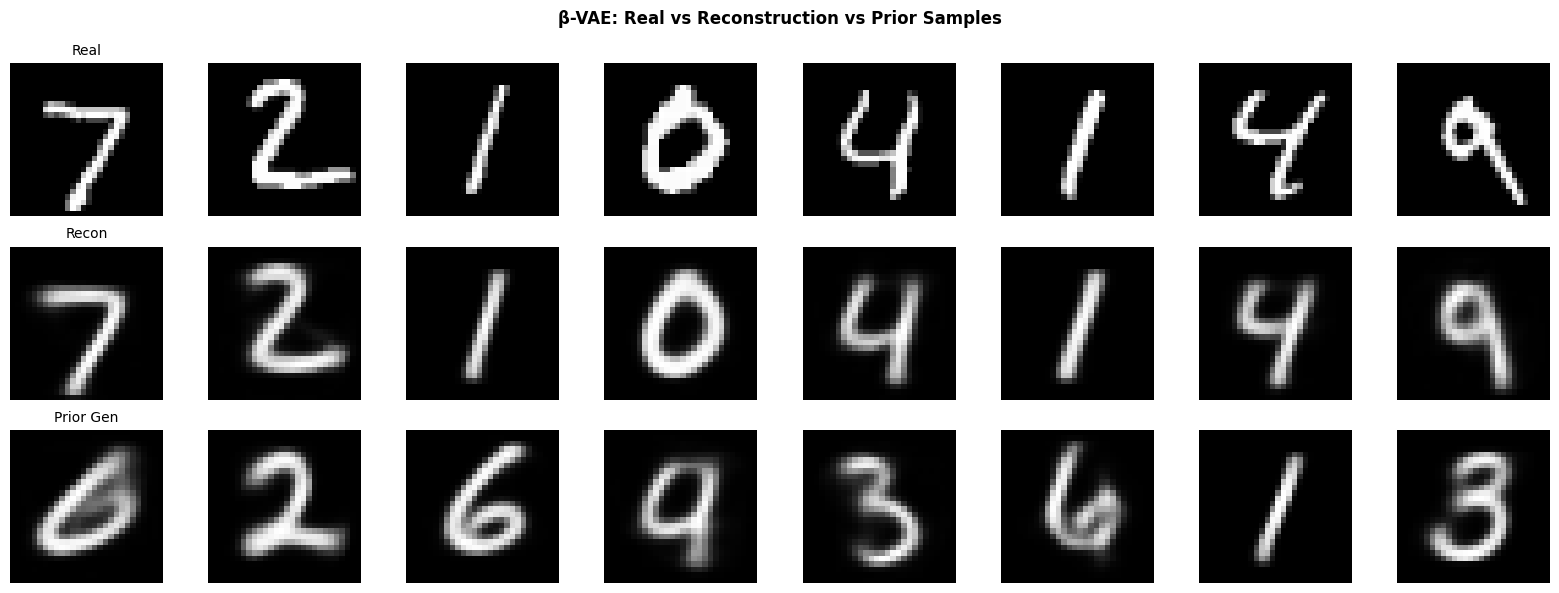

✓ β-VAE quality check saved to beta_vae_quality_check.png


In [7]:
# Show comparison: Real vs reconstruction vs prior sample
print('\n--- β-VAE Quality Check ---')

# Get real samples
real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    # Reconstruction quality (x -> z -> x_hat)
    q = latent_ddpm.vae.encode(real_flat)
    recon = latent_ddpm.vae.decode_mean(q.mean)

    # True generative quality (z ~ N(0,I) -> x)
    prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)

# Reshape for plotting
real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
gen_imgs = prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

# Display comparison
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')

    axes[2, i].imshow(gen_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('Prior Gen' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')

fig.suptitle('β-VAE: Real vs Reconstruction vs Prior Samples', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'beta_vae_quality_check.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ β-VAE quality check saved to beta_vae_quality_check.png')

In [8]:
# Stage 2: Train the latent DDPM
print('\nStage 2: Training DDPM in latent space...')
latent_ddpm.train_ddpm(train_loader, epochs=LDDPM_DDPM_EPOCHS, lr=LDDPM_DDPM_LR)

latent_ddpm.save(OUTDIR / 'latent_ddpm.pt')
print('Saved latent DDPM model.')


Stage 2: Training DDPM in latent space...


Training: 100%|██████████| 28140/28140 [03:12<00:00, 146.18it/s, epoch=30/30, loss=⠀      2.8009]


Saved latent DDPM model.



--- Latent DDPM Diagnostic ---
Comparing: VAE Prior Sampling vs Trained DDPM in Latent Space



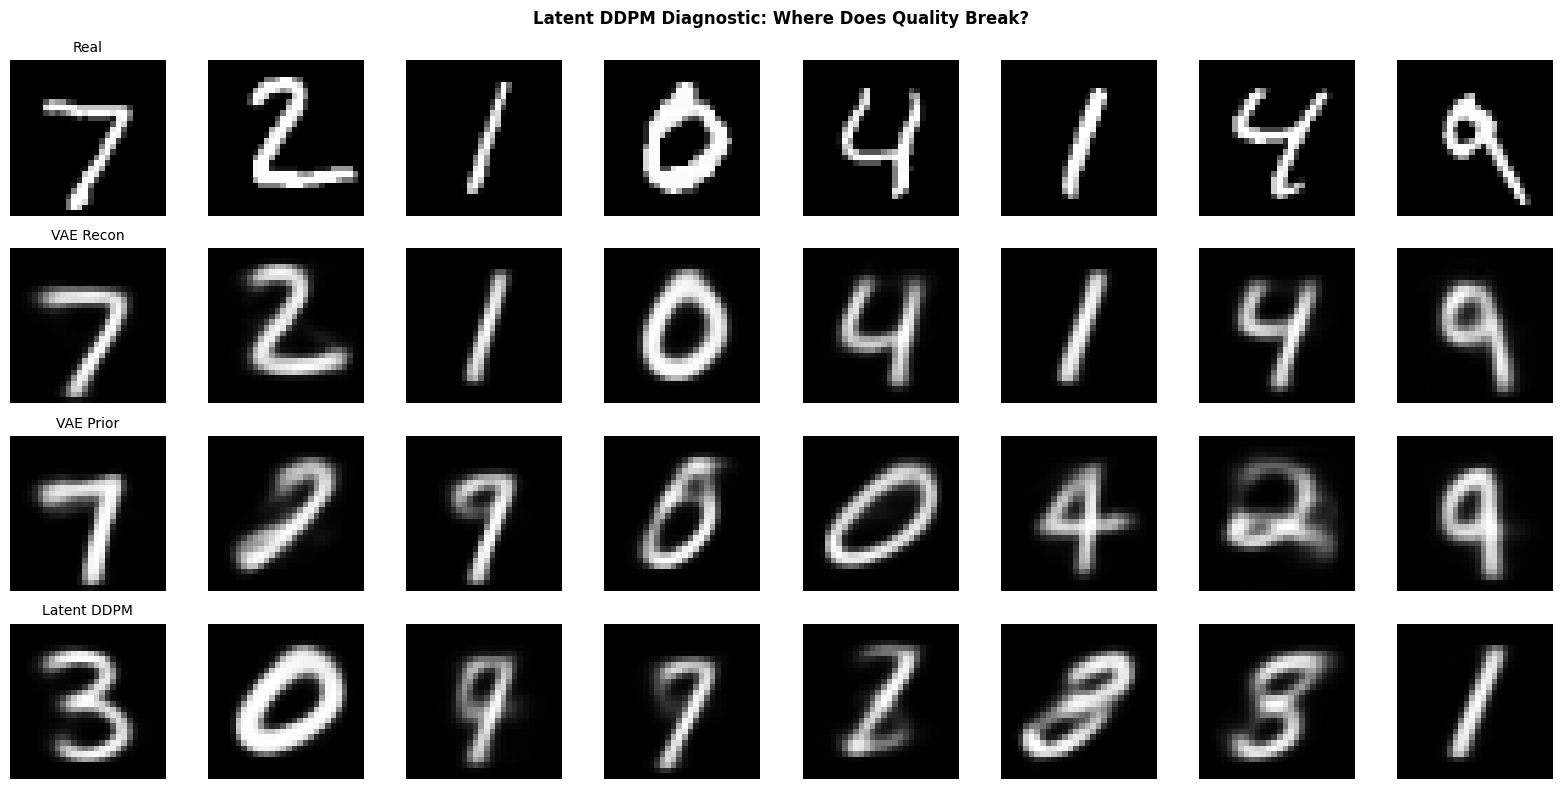

📊 DIAGNOSIS:
  Row 1 (Real): Ground truth
  Row 2 (VAE Recon): Should be sharp → checks if VAE encoder works
  Row 3 (VAE Prior): z ~ N(0,I) → checks if VAE prior is aligned
  Row 4 (Latent DDPM): z ~ DDPM → checks if DDPM improved the prior

If Row 3 is blurry: β is too low → increase β (try 5e-3)
If Row 3 is OK but Row 4 is worse: DDPM training failed → more epochs needed
✓ Diagnostic saved to latent_ddpm_diagnostic.png


In [ ]:
# DIAGNOSTIC: Compare VAE Prior vs Latent DDPM to isolate the problem
print('\n--- Latent DDPM Diagnostic ---')
print('Comparing: VAE Prior Sampling vs Trained DDPM in Latent Space\n')

# Get real samples
real_batch = next(iter(test_loader))
if isinstance(real_batch, (list, tuple)):
    real_batch = real_batch[0]
real_flat = real_batch[:8].to(device)
if real_flat.dim() > 2:
    real_flat = real_flat.view(real_flat.size(0), -1)

with torch.no_grad():
    # VAE reconstruction (baseline)
    q = latent_ddpm.vae.encode(real_flat)
    vae_recon = latent_ddpm.vae.decode_mean(q.mean)

    # VAE prior sampling (before DDPM improvement)
    vae_prior_gen = latent_ddpm.vae.sample(n_samples=8).to(device)

    # Latent DDPM samples (z_ddpm ~ DDPM → x = Decoder(z_ddpm))
    ddpm_samples = latent_ddpm.sample(n_samples=8).to(device)
    if ddpm_samples.dim() == 4:
        ddpm_samples = ddpm_samples.view(ddpm_samples.size(0), -1)

# Reshape for plotting
real_imgs = real_flat.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
recon_imgs = vae_recon.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
vae_prior_imgs = vae_prior_gen.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()
ddpm_imgs = ddpm_samples.view(-1, 1, 28, 28).clamp(0.0, 1.0).cpu()

# Display 4-row diagnostic
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i in range(8):
    axes[0, i].imshow(real_imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title('Real' if i == 0 else '', fontsize=10)
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_imgs[i, 0].numpy(), cmap='gray')
    axes[1, i].set_title('VAE Recon' if i == 0 else '', fontsize=10)
    axes[1, i].axis('off')

    axes[2, i].imshow(vae_prior_imgs[i, 0].numpy(), cmap='gray')
    axes[2, i].set_title('VAE Prior' if i == 0 else '', fontsize=10)
    axes[2, i].axis('off')

    axes[3, i].imshow(ddpm_imgs[i, 0].numpy(), cmap='gray')
    axes[3, i].set_title('Latent DDPM' if i == 0 else '', fontsize=10)
    axes[3, i].axis('off')

fig.suptitle('Latent DDPM Diagnostic: Where Does Quality Break?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTDIR / 'latent_ddpm_diagnostic.png', dpi=120, bbox_inches='tight')
plt.show()

# Diagnosis
print('📊 DIAGNOSIS:')
print('  Row 1 (Real): Ground truth')
print('  Row 2 (VAE Recon): Should be sharp → checks if VAE encoder works')
print('  Row 3 (VAE Prior): z ~ N(0,I) → checks if VAE prior is aligned')
print('  Row 4 (Latent DDPM): z ~ DDPM → checks if DDPM improved the prior')
print()
print('If Row 3 is blurry: β is too low → increase β (try 5e-3)')
print('If Row 3 is OK but Row 4 is worse: DDPM training failed → more epochs needed')
print('✓ Diagnostic saved to latent_ddpm_diagnostic.png')

## 2.2 DDPM U-Net (Pixel-space DDPM)

Training: 100%|██████████| 46900/46900 [32:54<00:00, 23.76it/s, epoch=50/50, loss=⠀     39.1614]


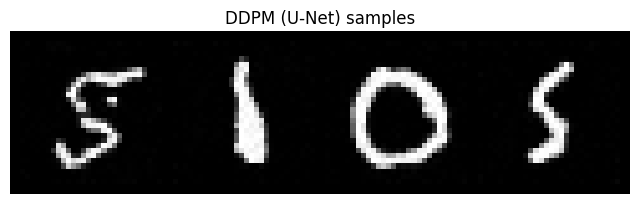

tensor([[[[0.0000e+00, 1.2347e-02, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [6.3514e-03, 2.4709e-04, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           9.5230e-04, 0.0000e+00],
          ...,
          [1.1783e-02, 0.0000e+00, 2.2541e-03,  ..., 9.1486e-03,
           4.5187e-03, 0.0000e+00],
          [0.0000e+00, 1.2021e-02, 3.0226e-03,  ..., 4.1724e-03,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           2.8872e-03, 1.3498e-02]]],


        [[[2.4006e-02, 5.4357e-03, 1.6988e-02,  ..., 2.3746e-03,
           2.7124e-03, 0.0000e+00],
          [9.7528e-04, 2.9316e-03, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [8.0643e-03, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 7.4234e-03, 4.5331e-03,  ..., 8.43

In [10]:
ddpm = DDPMUNetModel(device=device, T=DDPM_T)
ddpm.train_model(train_loader_ddpm, epochs=DDPM_UNET_EPOCHS, lr=DDPM_UNET_LR)
ddpm.save(OUTDIR / 'ddpm_unet.pt')
show_samples(ddpm, n=4, title='DDPM (U-Net) samples',
             save_path=OUTDIR / 'sa'
             'mples_ddpm_unet.png')

## 2.3 ⬜ VAE (Placeholder)

Implement in `project/models/vae_model.py`, then uncomment below.

In [11]:
# TODO: Uncomment once VAE is implemented in models/vae_model.py
# vae = VAEModel(device=device, beta=1.0, latent_dim=LATENT_DIM, hidden=VAE_HIDDEN)
# vae.train_model(train_loader, epochs=50, lr=1e-3)
# vae.save(OUTDIR / 'vae.pt')
# show_samples(vae, n=4, title='VAE samples', save_path=OUTDIR / 'samples_vae.png')
print('VAE not yet implemented — skipping.')

VAE not yet implemented — skipping.


---
# 3. Evaluation

## 3.1 Visual Comparison: Real MNIST vs Generated Samples

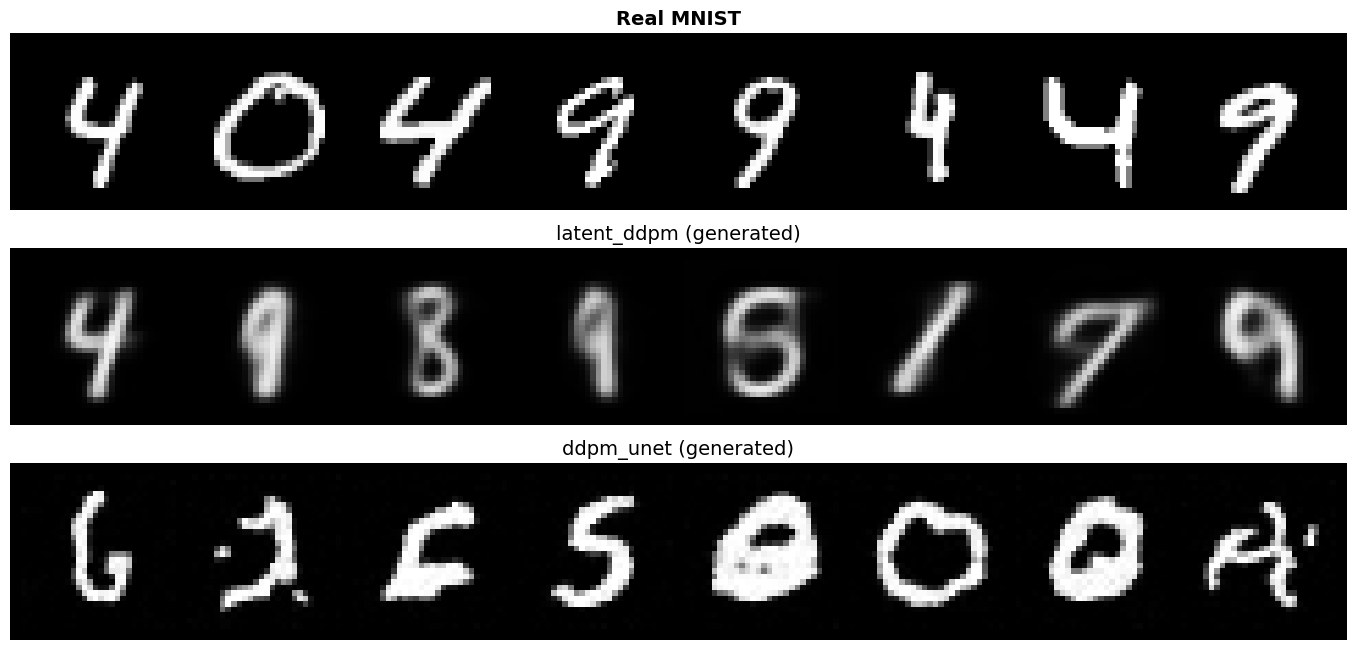

In [12]:
def show_comparison(real_loader, models, n_samples=8, save_path=None):
    """Top row = real MNIST, then one row per model with generated samples."""
    real_batch = next(iter(real_loader))
    if isinstance(real_batch, (list, tuple)):
        real_batch = real_batch[0]
    real_imgs = real_batch[:n_samples].cpu()
    if real_imgs.dim() == 2:
        real_imgs = real_imgs.view(-1, 1, 28, 28)
    real_imgs = real_imgs.clamp(0.0, 1.0)

    n_rows = 1 + len(models)
    fig, axes = plt.subplots(n_rows, 1, figsize=(n_samples * 2, 2.2 * n_rows))
    if n_rows == 1:
        axes = [axes]

    grid_real = make_grid(real_imgs, nrow=n_samples, padding=2, normalize=False)
    axes[0].imshow(grid_real.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
    axes[0].set_title('Real MNIST', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    for i, m in enumerate(models):
        with torch.no_grad():
            gen = m.sample(n_samples).cpu().clamp(0.0, 1.0)
        if gen.dim() == 2:
            gen = gen.view(-1, 1, 28, 28)
        grid_gen = make_grid(gen, nrow=n_samples, padding=2, normalize=False)
        axes[i + 1].imshow(grid_gen.permute(1, 2, 0).squeeze(-1).numpy(), cmap='gray')
        axes[i + 1].set_title(f'{m.name} (generated)', fontsize=14)
        axes[i + 1].axis('off')

    plt.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

# List of trained models (add vae once implemented)
models_to_eval = [latent_ddpm, ddpm]

show_comparison(
    train_loader, models_to_eval, n_samples=8,
    save_path=OUTDIR / 'comparison_real_vs_generated.png',
)

## 3.2 FID Scores

In [13]:
fid_results = {}
for m in models_to_eval:
    fid = evaluate_fid(m, n_gen=N_FID, device=device)
    fid_results[m.name] = fid
    print(f'{m.name:20s}  FID = {fid:.2f}')

latent_ddpm           FID = 231.41
ddpm_unet             FID = 45.18


## 3.3 FID vs β (Latent DDPM)

Sweep over different β values for the β-VAE inside the Latent DDPM.


--- β = 1e-06 ---


Training: 100%|██████████| 28140/28140 [03:24<00:00, 137.49it/s, epoch=30/30, loss=⠀      6.9012]


  β=1.0e-06  →  FID=28.46

--- β = 0.0001 ---


Training: 100%|██████████| 28140/28140 [03:23<00:00, 138.59it/s, epoch=30/30, loss=⠀      6.2588]


  β=1.0e-04  →  FID=31.59

--- β = 0.01 ---


...

  β=1.0e-02  →  FID=50.83

--- β = 0.1 ---


Training: 100%|██████████| 28140/28140 [03:22<00:00, 139.25it/s, epoch=30/30, loss=⠀      3.9579]


  β=1.0e-01  →  FID=75.70

--- β = 1.0 ---


Training: 100%|██████████| 28140/28140 [03:21<00:00, 139.65it/s, epoch=30/30, loss=⠀      1.1939]


  β=1.0e+00  →  FID=227.69


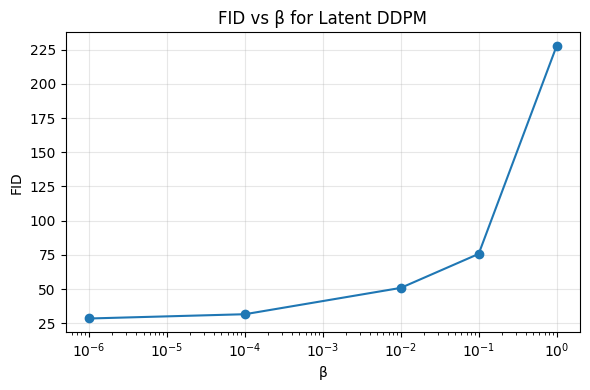

  β = 1.0e-06  →  FID = 28.46
  β = 1.0e-04  →  FID = 31.59
  β = 1.0e-02  →  FID = 50.83
  β = 1.0e-01  →  FID = 75.70
  β = 1.0e+00  →  FID = 227.69


In [14]:
# β values to sweep (adjust as needed)
betas_to_test = [1e-6, 1e-4, 1e-2, 1e-1, 1.0]

beta_fid_results = fid_vs_beta(
    betas=betas_to_test,
    train_loader=train_loader,
    device=device,
    latent_dim=LATENT_DIM,
    vae_epochs=LDDPM_VAE_EPOCHS,
    ddpm_epochs=LDDPM_DDPM_EPOCHS,
    n_fid=N_FID,
    save_path=OUTDIR / 'fid_vs_beta.png',
)

for b, f in beta_fid_results.items():
    print(f'  β = {b:.1e}  →  FID = {f:.2f}')

## 3.4 Sampling Speed

In [15]:
speed_results = {}
for m in models_to_eval:
    sr = measure_sampling_speed(m, n_samples=100)
    speed_results[m.name] = sr
    print(f"{m.name:20s}  {sr['samples_per_sec']:.1f} samples/s  "
          f"({sr['total_time_s']:.2f}s for {sr['n_samples']} samples)")

latent_ddpm           97.9 samples/s  (1.02s for 100 samples)
ddpm_unet             5.4 samples/s  (18.43s for 100 samples)


## 3.5 Summary Table

In [16]:
print(f"{'Model':<20} {'FID':>10} {'Samples/s':>12}")
print(f"{'-'*44}")
for name in fid_results:
    fid = fid_results[name]
    sps = speed_results[name]['samples_per_sec']
    print(f"{name:<20} {fid:>10.2f} {sps:>12.1f}")

Model                       FID    Samples/s
--------------------------------------------
latent_ddpm              231.41         97.9
ddpm_unet                 45.18          5.4


## 3.6 Latent Space Analysis

Compare three distributions in the first two latent dimensions:
- **VAE prior** — $\mathcal{N}(0, I)$
- **Aggregate posterior** — $\frac{1}{N} \sum q(z \mid x_i)$
- **Learned DDPM prior** — samples from the latent-space DDPM

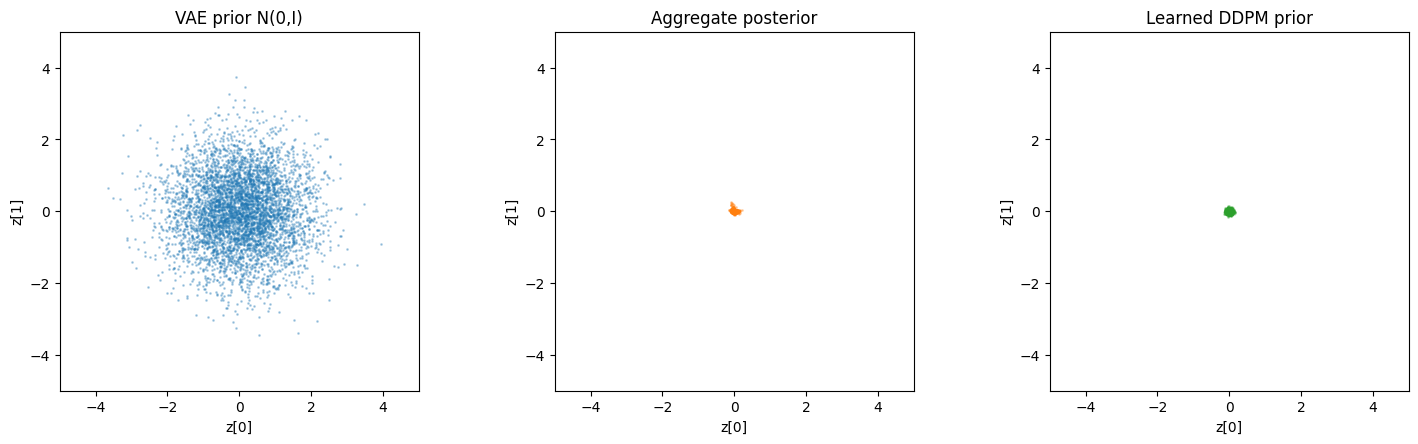

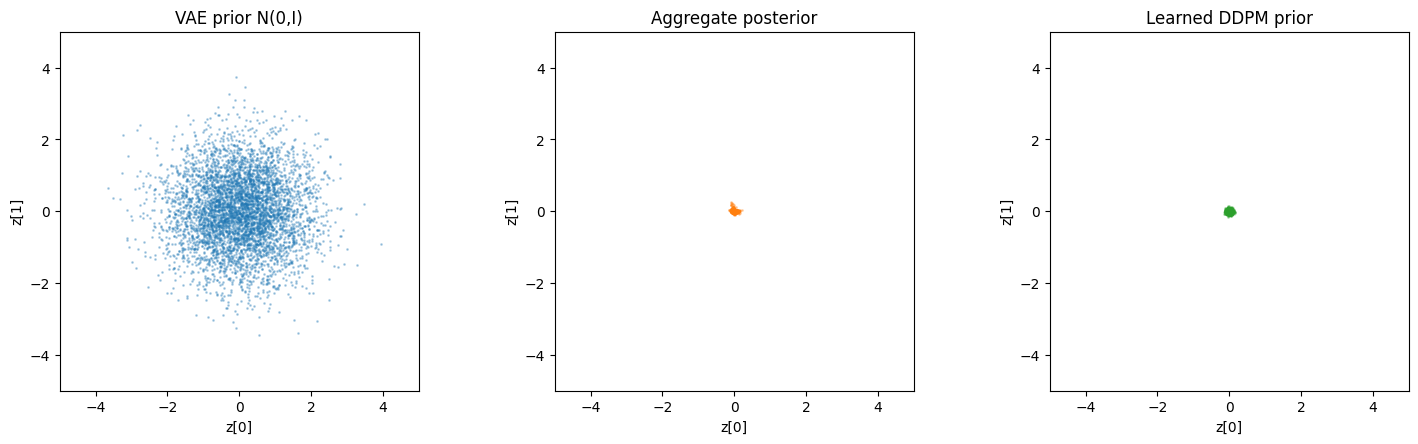

In [17]:
plot_latent_distributions(
    latent_ddpm,
    train_loader,
    dims=(0, 1),
    n_samples=5000,
    save_path=OUTDIR / 'latent_distributions.png',
)

---
# 4. Discussion

*Write your comparison / discussion of the three models here:*

- **Sample quality**: …
- **FID scores**: …
- **Sampling speed**: …
- **Effect of β**: …
- **Architecture notes**: …